-------------------------
##### This Notebook demonstrates how to use pretrained OpenAI embeddings of Wikipedia articles dataset. These embeddings are created using the model text-embedding-3-small

- against a pre-created dataset (with GPT vectors of dim 1536)

- MUST download the data (participants)
-----------------------------

In [136]:
#pip install wget

In [2]:
import openai
import pandas as pd
import os
#import wget
from ast import literal_eval

In [3]:
# Chroma's client library for Python
import chromadb

import warnings

warnings.filterwarnings(action="ignore", message="unclosed", category=ResourceWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning) 

In [4]:
EMBEDDING_MODEL = "text-embedding-3-small"

#### Load Data

In [5]:
embeddings_url = 'https://cdn.openai.com/API/examples/data/vector_database_wikipedia_articles_embedded.zip'

# The file is ~700 MB so this will take some time ... 3 mins
# wget.download(embeddings_url, out=r'D:\AI-DATASETS\02-MISC-large\GenAI-LLMs\chromadb')# 

In [3]:
# import zipfile
# zip_location = r'D:\AI-DATASETS\02-MISC-large\GenAI-LLMs\chromadb\vector_database_wikipedia_articles_embedded.zip'
# unzip_location = r'D:\AI-DATASETS\02-MISC-large\GenAI-LLMs\chromadb\data'

# with zipfile.ZipFile(zip_location,"r") as zip_ref:
#     zip_ref.extractall(unzip_location)

... From here ...

In [6]:
# huge dataset 1.7GB
csv_location = r'D:\Makesh\Working\AI\RPS\Day06-22 Nov\Datasets\vector_database_wikipedia_articles_embedded\vector_database_wikipedia_articles_embedded.csv'

In [7]:
article_df = pd.read_csv(csv_location)
article_df.shape

(25000, 7)

In [8]:
article_df.sample(5)

,id,url,title,text,title_vector,content_vector,vector_id
6541,20611,https://simple.wikipedia.org/wiki/Anguilla,Anguilla,Anguilla is a group of five islands in the Car...,"[-0.007021256722509861, -0.002896349411457777,...","[0.01221722736954689, 0.0009792920900508761, -...",6541
15893,60947,https://simple.wikipedia.org/wiki/2002%20Atlan...,2002 Atlantic hurricane season,The 2002 Atlantic hurricane season was a buzzw...,"[-0.028151700273156166, -0.009707941673696041,...","[-0.034312766045331955, -0.0018648242112249136...",15893
3772,11334,https://simple.wikipedia.org/wiki/Trikala,Trikala,Trikala is a Greek city and it is one of 51 pr...,"[-0.016002753749489784, 0.00042665257933549583...","[0.02655027061700821, 0.015930162742733955, 0....",3772
2068,7079,https://simple.wikipedia.org/wiki/Quechua,Quechua,"Quechua, sometimes written Quichua or Ketchua,...","[-0.0013537216000258923, 0.015201302245259285,...","[0.005413500126451254, 0.04307723045349121, 0....",2068
6947,21916,https://simple.wikipedia.org/wiki/Kelp%20forest,Kelp forest,Kelp forests are a type of marine ecosystem th...,"[0.029926210641860962, 0.009282667189836502, 0...","[0.028852665796875954, 0.005847282707691193, 0...",6947


**About `article_df`**
 
This DataFrame contains the following types of data for each Wikipedia article:
- The article's title and text content.
- Precomputed embedding vectors for both the title and the content (as string representations of lists).
- A unique `vector_id` for each article.
 
The DataFrame is used as the main dataset for vector search and retrieval experiments in the notebook, including sampling, vector conversion, and querying with ChromaDB.

In [9]:
article_df.dtypes

id                 int64
url               object
title             object
text              object
title_vector      object
content_vector    object
vector_id          int64
dtype: object

In [10]:
# Set the maximum column width to 100 characters
pd.set_option('display.max_colwidth', 100)

In [11]:
article_df[['title',	'text']].sample(10)

,title,text
14088,Camouflage (disambiguation),Camouflage can mean:\n\nCamouflage: protective colouration of living things\nMilitary camouflage...
3415,Mecklenburg-Vorpommern,Mecklenburg-Vorpommern or known by its anglicized name: Mecklenburg-Western Pomerania or Mecklen...
19079,Bălţi,Bălţi is the third-largest city in the country of Moldova. It is the major city in the northern ...
19435,Anna Göldi,"Anna Göldi (or Anna Göldin, Göldin is the female form of the name) (24 October 1734 - 13 June 17..."
19964,German-speaking Community of Belgium,"The German-speaking Community of Belgium (, short DGB) is one of the three federal communities i..."
7312,World Youth Day,World Youth Day (WYD) is a gathering (meeting) of young Catholic people. It was created by Pope ...
3753,Olympia,"Olympia ( Olympía) was a place in ancient Greece. It was in Elis, which is now called Ilia; and ..."
6770,Mutilation,Mutilation is when the way a human body looks is permanently changed. This change may be due to ...
8729,Raam,Ram is the son of Lord Surya and Seventh Avatar of Vishnu in Hinduism. However in Valmiki Ramaya...
11833,Psittacosaurus,"is a small ceratopsian dinosaur from the Lower Cretaceous of what is now Asia, about 130 to 100 ..."


In [16]:
article_df_1500 = article_df.sample(1500)

In [17]:
%%time
# Read vectors from strings back into a list
article_df_1500['title_vector']   = article_df_1500.title_vector.apply(literal_eval)
article_df_1500['content_vector'] = article_df_1500.content_vector.apply(literal_eval)

CPU times: total: 9.58 s
Wall time: 9.89 s


- Convert string representations of vectors back into Python list objects
- This is necessary because vectors saved as strings (e.g., in a CSV or database) need to be 
- converted back to lists to be used in calculations or machine learning models.

Explanation:
- literal_eval safely evaluates a string containing a Python expression (like a list) and converts it into a corresponding Python object.
- When vectors are stored in a DataFrame as strings (e.g., "[0.25, 0.89, 0.56]"), 
- we need to convert them back into actual lists (e.g., [0.25, 0.89, 0.56]) for further use.


**let us check the title and content vector dimensions**

In [18]:
len(article_df_1500.iloc[0]['title_vector']), len(article_df_1500.iloc[0]['content_vector'])

(1536, 1536)

In [19]:
# Set vector_id to be a string
article_df_1500['vector_id'] = article_df_1500['vector_id'].apply(str)

In [20]:
article_df_1500.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 1500 entries, 3448 to 7381
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              1500 non-null   int64 
 1   url             1500 non-null   object
 2   title           1500 non-null   object
 3   text            1500 non-null   object
 4   title_vector    1500 non-null   object
 5   content_vector  1500 non-null   object
 6   vector_id       1500 non-null   object
dtypes: int64(1), object(6)
memory usage: 93.8+ KB


#### Using Chroma DB

- `Instantiate the Chroma Client`

    - We'll start by creating a client instance to interact with the Chroma database.
    
- `Create Collections for Each Class of Embedding`

    - Collections in Chroma allow you to group embeddings based on specific criteria or use cases. Each collection can store embeddings that correspond to a particular class or type, such as text embeddings, image embeddings, etc.
    
- `Query Each Collection`

    - Finally, we'll perform queries on each collection to find the most similar embeddings. This could be used for tasks such as document retrieval, semantic search, or recommendation systems.

#### Instantiate the Chroma client

Create the Chroma client. By default, Chroma is ephemeral and runs in memory. However, you can easily set up a persistent configuration which writes to disk.

In [21]:
chroma_client = chromadb.EphemeralClient() 

# Equivalent to chromadb.Client(), ephemeral.
# Uncomment for persistent client
# chroma_client = chromadb.PersistentClient()

#### Embedding fn
Chroma collections allow you to store and filter with arbitrary metadata, making it easy to query subsets of the embedded data.

Chroma is already integrated with OpenAI's embedding functions. The best way to use them is on construction of a collection, as follows

In [22]:
from chromadb.utils.embedding_functions import OpenAIEmbeddingFunction

In [155]:
# Test that your OpenAI API key is correctly set as an environment variable
# Note. if you run this notebook locally, you will need to reload your terminal and the notebook for the env variables to be live.

# Note. alternatively you can set a temporary env variable like this:
# os.environ["OPENAI_API_KEY"] = 'sk-xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx'

In [23]:
import openai, os

In [24]:
# Load OpenAI API key from environment variables
openai_api_key = os.getenv('OPENAI_API_KEY')

In [32]:
embedding_function = OpenAIEmbeddingFunction(
    api_key   = openai_api_key, 
    model_name= EMBEDDING_MODEL)

In [49]:
chroma_client.delete_collection("wikipedia_titles")

In [50]:
chroma_client.delete_collection("wikipedia_content")


In [51]:
wikipedia_content_collection = chroma_client.create_collection(name='wikipedia_content', 
                                                               embedding_function=embedding_function)

wikipedia_title_collection   = chroma_client.create_collection(name='wikipedia_titles', 
                                                               embedding_function=embedding_function)

In [45]:
wikipedia_content_collection = chroma_client.create_collection(name='wikipedia_content')

wikipedia_title_collection   = chroma_client.create_collection(name='wikipedia_titles')

#### Populate the collections
Chroma collections allow you to populate, and filter on, whatever metadata you like. Chroma can also store the text alongside the vectors, and return everything in a single query call, when this is more convenient.

For this use-case, we'll just store the `embeddings` and `IDs`, and use these to index the original dataframe.

In [52]:
# Add the content vectors
wikipedia_content_collection.add(
    ids       = article_df_1500.vector_id.tolist(),
    embeddings= article_df_1500.content_vector.tolist(),
)

# Add the title vectors
wikipedia_title_collection.add(
    ids       = article_df_1500.vector_id.tolist(),
    embeddings= article_df_1500.title_vector.tolist(),
)

#### Search the collections
Chroma handles embedding queries for you if an embedding function is set

In [57]:
def query_collection(collection, query, max_results, dataframe):
    
    results = collection.query(query_texts= query, 
                               n_results  = max_results, 
                               include    = ['distances']) 
    
    df = pd.DataFrame({
                'id':results['ids'][0], 
                'score':results['distances'][0],
                'title': dataframe[dataframe.vector_id.isin(results['ids'][0])]['title'],
                'content': dataframe[dataframe.vector_id.isin(results['ids'][0])]['text'],
                })
    
    return df

In [58]:
title_query_result = query_collection(
    collection = wikipedia_title_collection,
    query      = "Footballer",
    max_results= 10,
    dataframe  = article_df_1500
)

title_query_result.head()

,id,score,title,content
4786,13264,1.954597,Epididymitis,"Epididymitis is a painful inflammation of the epididymis, usually resulting from bacterial infec..."
192,14238,1.962332,Interim,"Interim means ""in between"" or ""transitional"" (moving from one time or place to another), or ""tem..."
24628,5479,1.963518,Skjaldbreiður,"Skjaldbreiður(Skyald-bray-thur) is a volcano in Iceland. It is 1,060 metres tall, and its crater..."
7456,13184,1.974620,Boeing 747,The Boeing 747 is a jet airliner developed by Boeing in 1969. It is made by Boeing Commercial Ai...
381,4786,1.975364,Search engine,A search engine is a website that allows users to look up information on the World Wide Web (WWW...


In [55]:
content_query_result = query_collection(
    collection=wikipedia_content_collection,
    query="Famous battles in Scottish history",
    max_results=10,
    dataframe=article_df_1500
)
content_query_result.head()

,id,score,title,content
17694,22262,1.924988,Chinese calendar,"The Chinese calendar, also known as the ""agriculture calendar"" (農曆/农历), is a lunisolar calendar ..."
18618,11166,1.941882,Knight Bachelor,"In the United Kingdom, a Knight Bachelor is a man who is a knight, (has the title Sir) but who i..."
3166,18618,1.948414,February 28,"In a common year this is the last day of February, and the next day is March 1. In Leap years, F..."
22262,16774,1.949754,480,\n\nEvents\n\nBy place\n\nEurope \n Odoacer stops an attempt by Julius Nepos to gain control of ...
24243,24243,1.950493,Caligula,"Caligula (Gaius Julius Caesar Augustus Germanicus, 31 August 12 – 24 January 41) was the third R..."


### Clustering Wikipedia Articles by Content Embeddings
 
In this section, we'll use KMeans clustering to group articles by their content embeddings, and visualize the clusters using PCA and t-SNE dimensionality reduction.

#### How to Choose the Number of Clusters?
 
The number of clusters (`n_clusters`) in KMeans is a parameter you set before running the algorithm. To find a good value:
 
- **Elbow Method**: Plot the sum of squared distances (inertia) for different `n_clusters` and look for the 'elbow' point where the decrease slows down.
- **Silhouette Score**: Calculate the silhouette score for different `n_clusters` values; higher scores indicate better-defined clusters.
 
Below are code cells to help you determine the optimal number of clusters.

In [59]:
!pip install scikit-learn

In [60]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

In [61]:
X = np.array(article_df_1500['content_vector'].tolist())

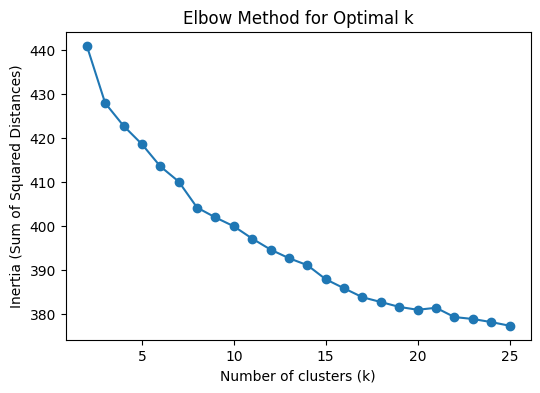

In [169]:
# Elbow Method: Plot inertia for different cluster counts
inertias = []
k_range = range(2, 26)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method for Optimal k')
plt.show()

**How to interpret the Elbow Method (SSE/Inertia):**
 
- The Elbow Method helps you choose the optimal number of clusters for KMeans by plotting the sum of squared errors (SSE, also called inertia) for different values of k (number of clusters).
- SSE measures how close each point in a cluster is to the cluster center; lower values mean tighter clusters.
 
**How to use the plot:**
- As k increases, SSE always decreases (clusters fit data better).
- Look for the "elbow" point in the plot:
    - Before the elbow, adding more clusters significantly reduces SSE.
    - After the elbow, the rate of improvement slows down.
- The optimal k is at the elbow—where increasing k further yields only marginal gains.
 
**Summary:**
The elbow point is a good trade-off between model complexity and clustering quality. Choose k at this point for a balanced solution.

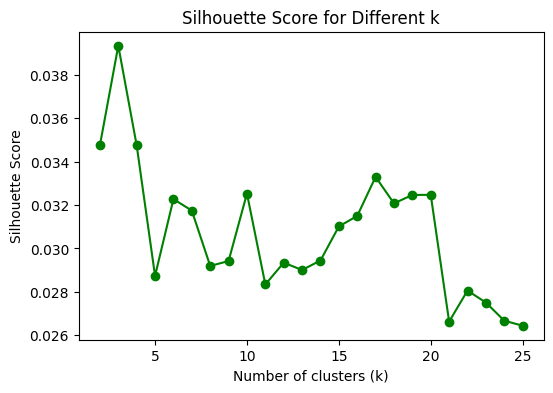

In [170]:
# Silhouette Score: Evaluate cluster quality for different k
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(k_range, silhouette_scores, marker='o', color='green')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different k')
plt.show()

**How to interpret the Silhouette Score:**
 
- The Silhouette Score measures how well each data point fits within its assigned cluster compared to other clusters.
- **Score Range:** -1 (poor clustering) to +1 (well-clustered). Values near 0 mean overlapping clusters; values close to 1 mean well-separated clusters.
 
**How to use the plot:**
- For each k (number of clusters), a higher silhouette score means better-defined, more separated clusters.
- The optimal k is where the silhouette score is highest (or near its peak), indicating the best cluster structure.
 
**Summary:**
Choose the number of clusters where the silhouette score is maximized for the best clustering quality.

**Silhouette Score Plot Interpretation:**

- The Silhouette Score plot shows the clustering quality for different numbers of clusters (k).
- The highest silhouette score occurs at k=3, indicating that 3 clusters provide the best separation and cohesion among clusters for your data.
- The score drops as k increases beyond 3, suggesting that adding more clusters does not improve the clustering quality and may even make it worse (clusters become less distinct).
- The scores for k > 7 remain low and relatively flat, indicating little benefit in increasing the number of clusters further.

**Conclusion:**
Based on this plot, k=3 is the optimal choice for the number of clusters, as it maximizes the silhouette score and thus the clustering quality for your embeddings.

In [171]:
# Select the embeddings for clustering (using the 1500-sample DataFrame)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

In [172]:
# Stack content vectors into a numpy array
X = np.stack(article_df_1500['content_vector'].values)

In [173]:
# Choose number of clusters (e.g., 8)
n_clusters = 8

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(X)


In [174]:
# Add cluster labels to DataFrame
article_df_1500['cluster'] = labels

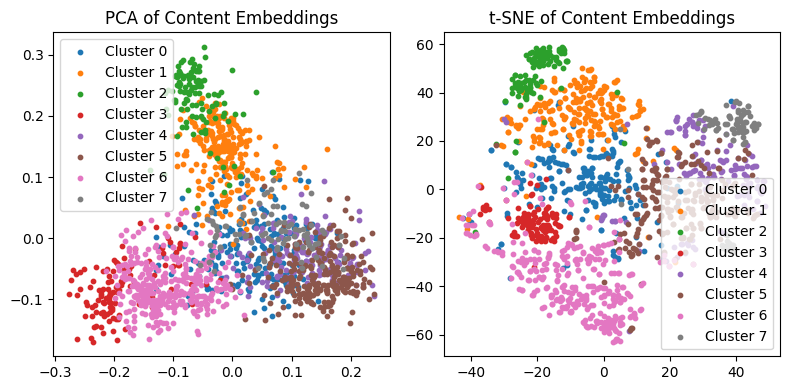

In [175]:
# Dimensionality reduction for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

# Plot PCA
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
for i in range(n_clusters):
    plt.scatter(X_pca[labels==i,0], X_pca[labels==i,1], label=f'Cluster {i}', s=10)
plt.title('PCA of Content Embeddings')
plt.legend()

# Plot t-SNE
plt.subplot(1,2,2)
for i in range(n_clusters):
    plt.scatter(X_tsne[labels==i,0], X_tsne[labels==i,1], label=f'Cluster {i}', s=10)
plt.title('t-SNE of Content Embeddings')
plt.legend()
plt.tight_layout()
plt.show()

In [176]:
!pip install umap-learn

d:\Makesh\Working\AI\Python_Envs\gen_ai\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


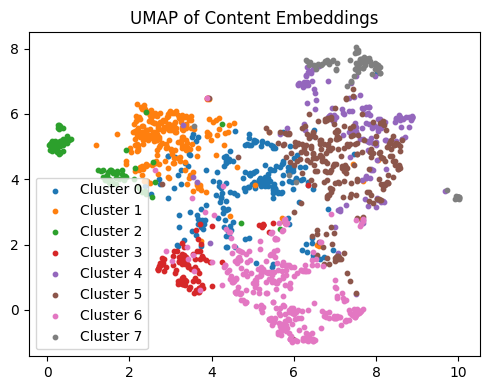

In [177]:
import umap
umap_reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_reducer.fit_transform(X)

# Plot UMAP
plt.figure(figsize=(5,4))
for i in range(n_clusters):
    plt.scatter(X_umap[labels==i,0], X_umap[labels==i,1], label=f'Cluster {i}', s=10)
plt.title('UMAP of Content Embeddings')
plt.legend()
plt.tight_layout()
plt.show()

### Key Analysis Points from t-SNE/UMAP Visualizations (for GenAI App Developers)

- **Cluster Structure:**
  - t-SNE and UMAP reveal clear groupings of articles, indicating that content embeddings capture meaningful topic clusters.
  - Well-separated clusters suggest the embeddings are effective for semantic grouping and retrieval tasks.

- **Outliers and Unique Topics:**
  - Isolated points or small groups in the visualization may represent outlier articles or unique topics not well covered by the main clusters.
  - These can be flagged for further review or special handling in GenAI applications.

- **Cluster Overlap:**
  - Some overlap between clusters may indicate articles with mixed or ambiguous topics, which could be useful for cross-topic recommendations.

- **Dimensionality Reduction Utility:**
  - t-SNE and UMAP help validate the quality of embeddings and clustering, providing visual feedback for model or data improvements.
  - These methods are valuable for debugging, feature engineering, and communicating results to stakeholders.

- **Application Implications:**
  - Strong cluster separation supports use cases like topic-based search, recommendation, and content organization in GenAI apps.
  - Outlier detection can enhance content moderation, novelty detection, or highlight unique knowledge areas.

### Outlier Detection: Identifying Unique or Distant Articles

We can identify articles whose embeddings are far from all others (potential outliers or unique topics) by measuring their distance from the cluster centers or from their nearest neighbors in the embedding space. Outliers may represent articles with unique content or topics not well represented in the main clusters.

In [178]:
# Outlier Detection using Distance from Cluster Centers
# Articles farthest from their assigned cluster center can be considered outliers.

from sklearn.metrics import pairwise_distances
import numpy as np

# Compute distances to assigned cluster center for each article
cluster_centers = kmeans.cluster_centers_
distances = np.linalg.norm(X - cluster_centers[labels], axis=1)

# Add distances to DataFrame
article_df_1500['distance_to_center'] = distances

# Identify top 10 outliers (largest distances)
outlier_indices = np.argsort(distances)[-10:][::-1]
outliers = article_df_1500.iloc[outlier_indices][['title', 'distance_to_center', 'cluster']]

print("Top 10 Outlier Articles:")
display(outliers)

Top 10 Outlier Articles:


,title,distance_to_center,cluster
15431,Cruiserweight,0.605705,6
23944,Palindromic prime,0.600758,5
11549,Windows Neptune,0.598159,4
12734,Xubuntu,0.586973,4
15833,Cardiomyopathy,0.585108,4
23681,9-9-9,0.583555,0
1084,List of colors,0.583470,4
22663,PeaZip,0.580914,4
23166,LG Prada,0.580836,4
9100,Celestia,0.580667,4


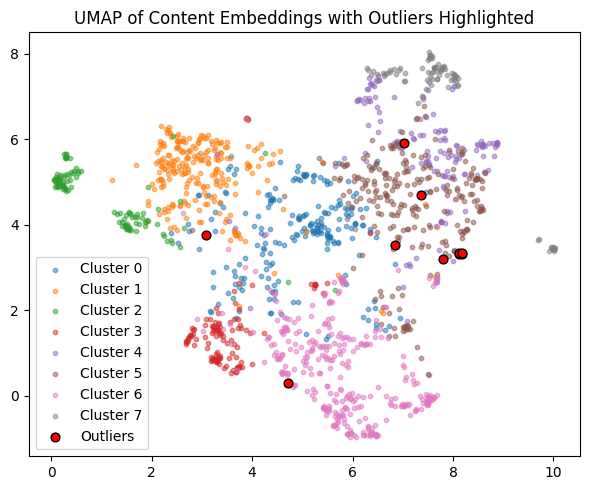

In [179]:
# Visualize Outliers on UMAP Plot
plt.figure(figsize=(6,5))

for i in range(n_clusters):
    plt.scatter(X_umap[labels==i,0], X_umap[labels==i,1], label=f'Cluster {i}', s=10, alpha=0.5)
    
# Highlight outliers in red
plt.scatter(X_umap[outlier_indices,0], X_umap[outlier_indices,1], color='red', s=40, label='Outliers', edgecolor='black')
plt.title('UMAP of Content Embeddings with Outliers Highlighted')
plt.legend()
plt.tight_layout()
plt.show()

### Key Takeaways from Outlier Analysis

- Outlier articles are those whose embeddings are farthest from their cluster centers, indicating unique or atypical content compared to the main topics.
- Visualizing outliers on the UMAP plot helps quickly identify articles that do not fit well into any cluster, which may represent rare, novel, or highly specialized topics.
- For GenAI applications, these outliers can:
  - Highlight gaps or unique areas in the dataset.
  - Be prioritized for review, curation, or special handling (e.g., moderation, novelty detection).
  - Inform improvements in data collection, labeling, or embedding strategies.
- Outlier detection adds an extra layer of insight beyond standard clustering, supporting better content understanding and quality control in GenAI workflows.

### Metadata Filtering: Refining Search Results

You can enhance search and retrieval by filtering articles using metadata such as article length or category. This allows you to:
- Focus on articles of a certain type, length, or topic.
- Exclude irrelevant or overly short/long articles.
- Combine semantic search with structured filters for more precise results.

Below is an example of how to filter articles by length and (if available) by category before or after a vector search.

In [180]:
# Example: Filter articles by length and (optionally) by category

# Add article length as metadata if not already present
article_df_1500['article_length'] = article_df_1500['text'].str.len()

# Example: Filter for articles with length between 1000 and 5000 characters
filtered_df = article_df_1500[(article_df_1500['article_length'] >= 1000) & (article_df_1500['article_length'] <= 5000)]

# If a 'category' column exists, filter by category as well (e.g., 'Science')
if 'category' in article_df_1500.columns:
    filtered_df = filtered_df[filtered_df['category'] == 'Science']

print(f"Filtered articles: {len(filtered_df)} out of {len(article_df_1500)}")
display(filtered_df[['title', 'article_length'] + (['category'] if 'category' in filtered_df.columns else [])].head(10))

Filtered articles: 592 out of 1500


,title,article_length
13544,Josef Mengele,1433
3636,Louis XIII,1072
9519,Frances Folsom Cleveland,2028
22911,"Baldwin County, Alabama",4765
12977,Substrate,1028
3629,Absolute zero,2637
13558,Militarism,1056
13304,Stain,1322
18758,Queer,1135
16525,Professional wrestling,1471
